In [15]:
import sys
sys.path.insert(0, '../')

import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import ipywidgets as widgets

from dataset_utils.dataset import StudioLiveDataset, StudioLiveDataModule

## Load and Inspect StudioLiveDataset

In [16]:
studio_dir = '../../datasetv2/studio'
live_dir = '../../datasetv2/live'
dataset = StudioLiveDataset(studio_dir, live_dir, sr=22050, segment_duration=0.5, context_length=16)
print('dataset length', len(dataset))
sample = dataset[0]
print('sample keys', sample.keys())
print('studio shape', sample['studio_audio'].shape)
print('live shape', sample['live_audio'].shape)

Aligning audio pairs: 100%|██████████| 17/17 [00:21<00:00,  1.25s/it]

{('../../datasetv2/studio/Circadian Rhythm.mp3', '../../datasetv2/live/Circadian Rhythm.mp3'): {'studio_audio': array([ 2.0833134e-04,  4.3943178e-04,  3.8178355e-04, ...,
        1.4874890e-01, -2.1155486e-01,  1.4184973e-01],
      shape=(1444473,), dtype=float32), 'live_audio': array([ 1.0280793e-08,  7.3612574e-09,  3.8399861e-09, ...,
       -5.0438017e-02, -6.9976062e-02, -9.2406958e-02],
      shape=(1444473,), dtype=float32)}, ('../../datasetv2/studio/Energy.mp3', '../../datasetv2/live/Energy.mp3'): {'studio_audio': array([-2.9682130e-07, -6.2763110e-07, -6.0890449e-07, ...,
        9.8046884e-02,  2.1919939e-01,  3.0306679e-01],
      shape=(1896410,), dtype=float32), 'live_audio': array([ 2.0812112e-09, -1.4733523e-09,  9.8952113e-10, ...,
        1.2454936e-02,  2.0420018e-03, -2.2274340e-03],
      shape=(1896410,), dtype=float32)}, ('../../datasetv2/studio/Fake Love.mp3', '../../datasetv2/live/Fake Love.mp3'): {'studio_audio': array([-3.2816624e-05, -5.2434872e-05, -1.2619

## Define Mel Spectrogram and Inversion Utilities

In [17]:
def compute_mel(audio, sr, n_mels=128, hop_length=512, fmax=8000):
    # audio: 1d numpy array
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
    mel_db = librosa.power_to_db(mel)
    return mel_db

def mel_to_audio(mel_db, sr, n_iter=32, hop_length=512, fmax=8000):
    mag = librosa.db_to_power(mel_db)
    audio = librosa.feature.inverse.mel_to_audio(M=mag, sr=sr, hop_length=hop_length, fmax=fmax, n_iter=n_iter)
    return audio

## Compute Mel Variants for a Sample

In [18]:
# pick first sample studio segment
studio_audio = sample['studio_audio'].numpy()[-1]  # last slot
sr = dataset.sr
params = [
    {'n_mels':64,'hop_length':256},
    {'n_mels':128,'hop_length':512},
    {'n_mels':256,'hop_length':512},
]
mel_dict = {}
audio_dict = {}
for p in params:
    key = f"mels{p['n_mels']}_hop{p['hop_length']}"
    mel = compute_mel(audio=studio_audio, sr=sr, **p)
    mel_dict[key] = mel
    audio_dict[key] = mel_to_audio(mel_db=mel, sr=sr, hop_length=p['hop_length'])

## Visualize Mel Spectrograms

/tmp/ipykernel_643960/914073002.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


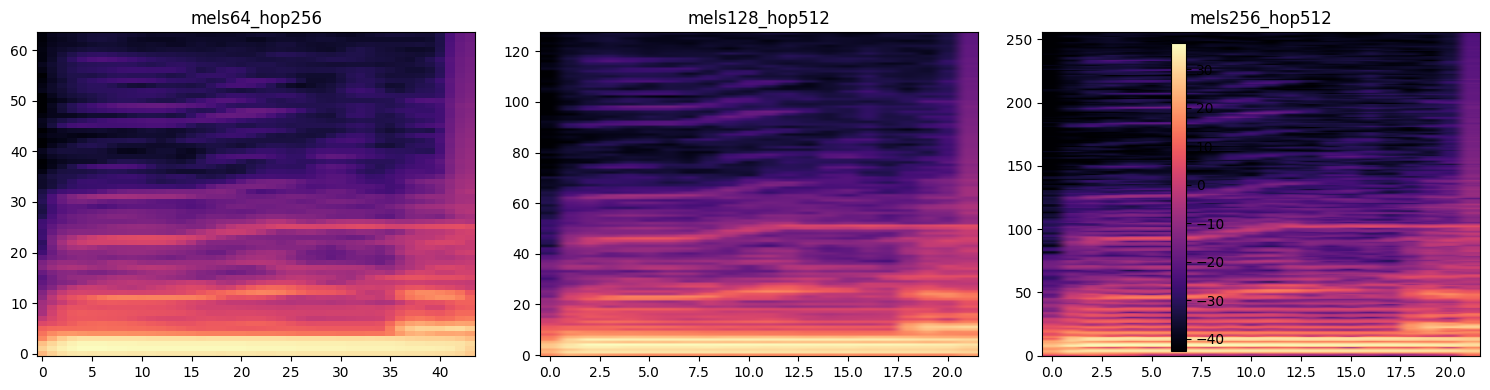

In [19]:
fig, axs = plt.subplots(1, len(mel_dict), figsize=(15,4))
for ax,(k,m) in zip(axs, mel_dict.items()):
    im = ax.imshow(m, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(k)
plt.colorbar(im, ax=axs.ravel().tolist())
plt.tight_layout()

## Play Audio Reconstructed from Different Mel Configurations

In [20]:
for k,a in audio_dict.items():
    print(k)
    display(Audio(a, rate=sr))

mels64_hop256


mels128_hop512


mels256_hop512
